In [1]:
import os
import pandas as pd
import sys
import matplotlib.pyplot as plt
import seaborn as sns

# Custom modules
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/'))
from spk_feat_cluster_comp_analysis import *
import config
from config import SPE1_PICKLE_ROOT, PRIORITY_CELLS

In [2]:
cluster_pickle_dir = "/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/cluster_pickles/"

## Load data

One row per (cell × spike_feature × cluster_pair). Columns: nRMSE, cos_sim, num_clusters, Spearman ρ (spike time × cluster label), and all metadata.

In [3]:
#create df for all experiments 
df_master = compile_experiment_results(cluster_pickle_dir)


In [4]:
df_master

,cell_id,patch_type,current_type,cell_type,cortical_depth,dark_neuron,clear_EAP_waveform,spike_feature,num_clusters,cluster,nRMSE,cos_sim,temporal_rho,temporal_p,temporal_component
0,c1,Juxta,IC,PC,843.9,False,False,peak_amp,3,Low-High,0.119418,0.971779,-0.791905,0.000000e+00,1.0
1,c1,Juxta,IC,PC,843.9,False,False,peak_sharpness,3,Low-High,0.107567,0.994407,-0.626985,3.884666e-187,1.0
2,c1,Juxta,IC,PC,843.9,False,False,exp_lambda,3,Low-High,0.070281,0.987561,-0.524866,1.803408e-121,1.0
3,c1,Juxta,IC,PC,843.9,False,False,log_isi,3,Low-Mid,0.054002,0.998812,0.318106,2.021776e-41,1.0
4,c1,Juxta,IC,PC,843.9,False,False,log_isi,3,Low-High,0.049643,0.998229,0.318106,2.021776e-41,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,c45,Juxta,VC,PC,1137.0,False,True,exp_lambda,3,Low-High,0.072935,0.944095,0.398502,4.885509e-256,1.0
146,c45,Juxta,VC,PC,1137.0,False,True,exp_lambda,3,Mid-High,0.172526,0.862314,0.398502,4.885509e-256,1.0
147,c45,Juxta,VC,PC,1137.0,False,True,log_isi,3,Low-High,0.053664,0.978564,-0.100840,9.668021e-17,1.0
148,c46,Juxta,VC,PC,1039.7,False,True,exp_lambda,2,Low-High,0.060821,0.973256,-0.056060,3.679477e-06,1.0


In [5]:
#sort by cell id
# Create a numeric column for sorting (c1, c2, c10, etc.)
df_master['sort_idx'] = df_master['cell_id'].str.extract('(\d+)').astype(int)

# Sort by the numeric ID, then by feature name
df_master = df_master.sort_values(by=['sort_idx', 'spike_feature']).drop(columns=['sort_idx'])



## Dataset overview

Full master table — all cells, all spike features, all cluster pairs.

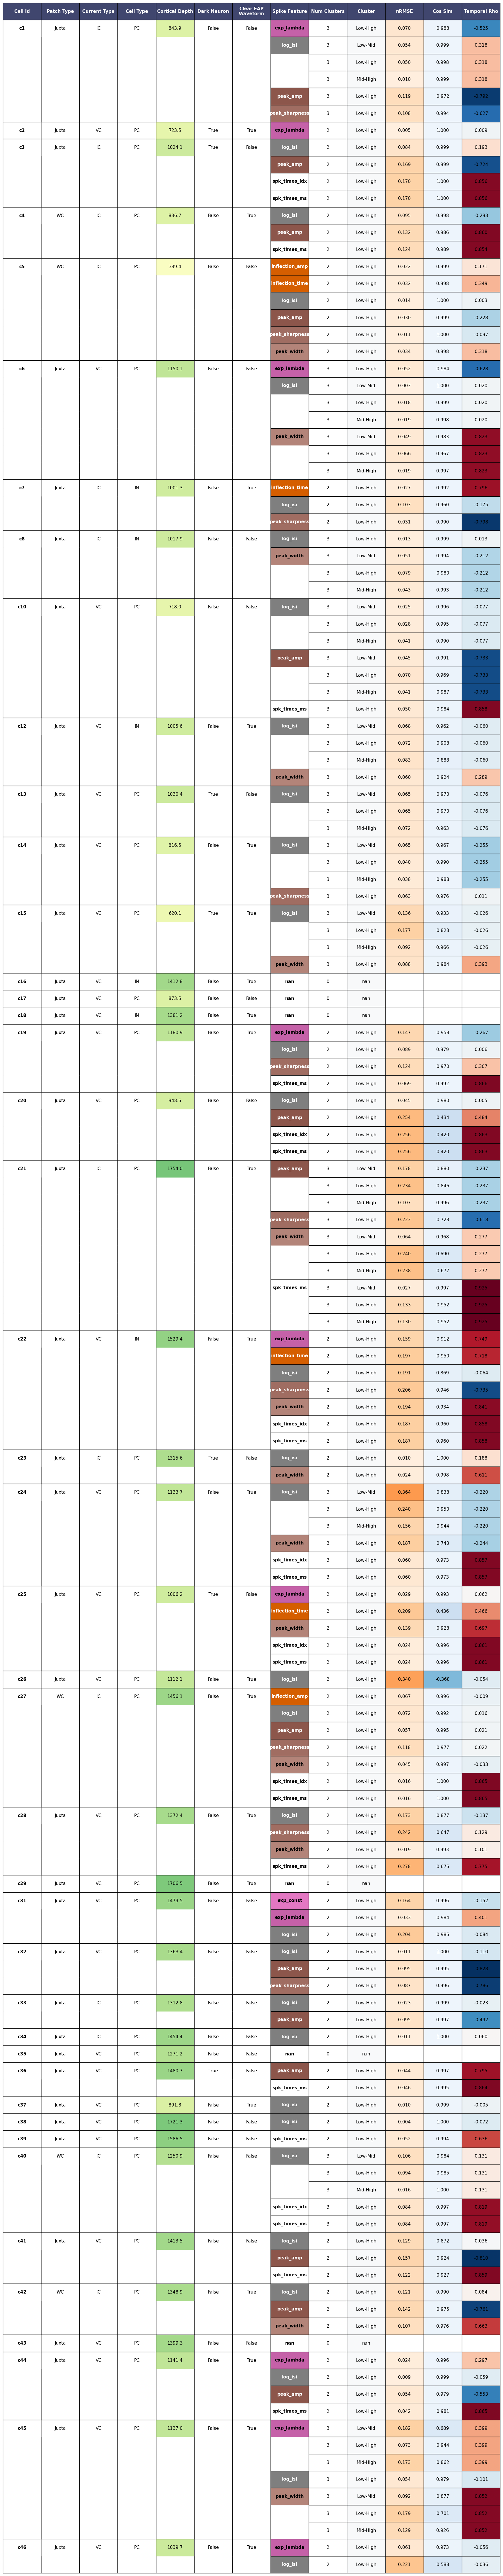

In [6]:

gen_table_fig(df_master)


## Are clustering results driven by biology or recording conditions?

Before interpreting waveform cluster differences as biology, we need to rule out recording artefacts. Three checks: metadata vs waveform difference between clusters, which features cluster at all, and whether cluster membership changes over recording time.

## A. Does recording metadata predict waveform difference between clusters?

Spearman ρ between each metadata variable (cell type, patch type, depth, etc.) and waveform difference metrics (nRMSE, cos_sim, num_clusters). BH-FDR corrected. A significant association = potential confound.

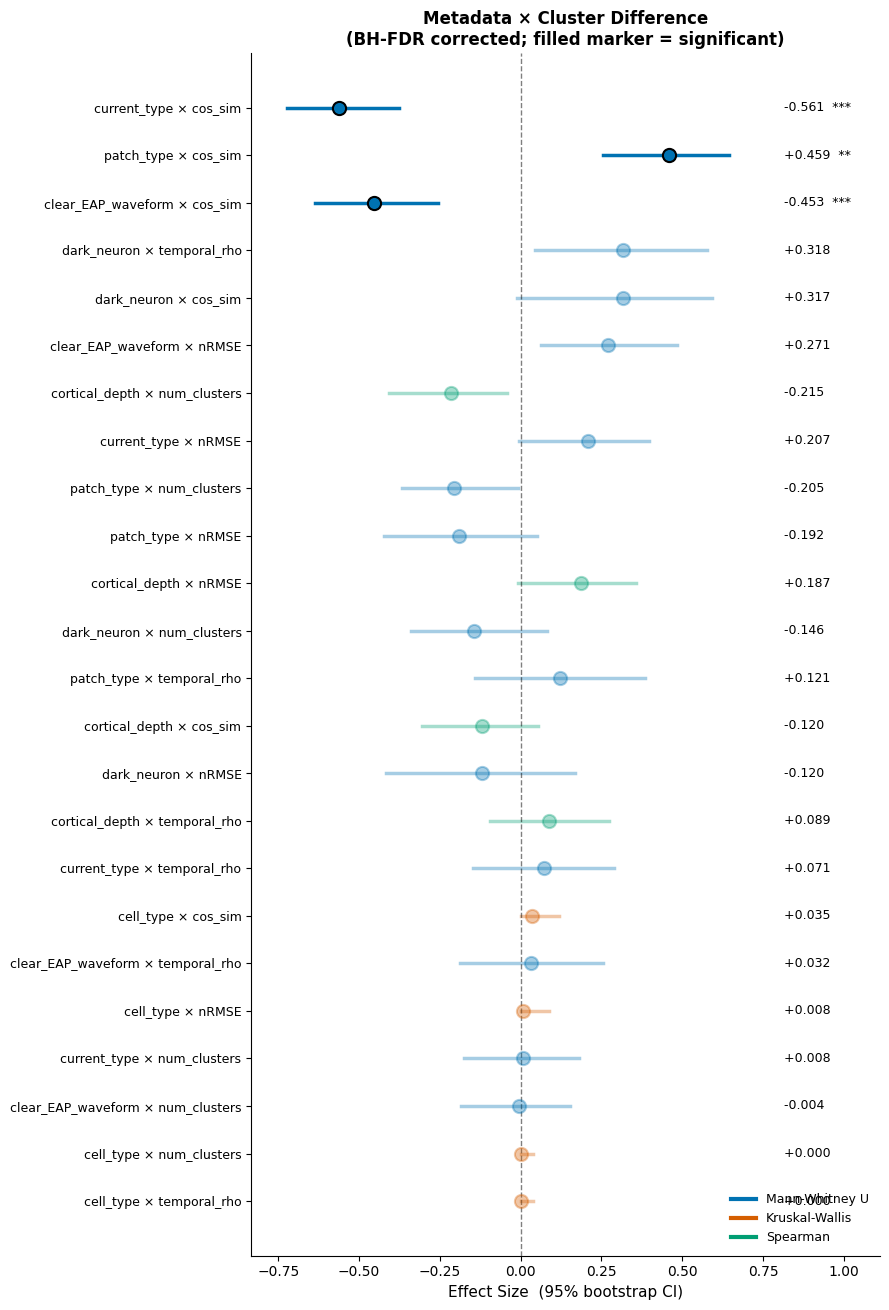


3/24 pairs significant after BH-FDR (α=0.05, n_bootstrap=1000):
  current_type           × cos_sim        | rank-biserial r = -0.561  95% CI [-0.722, -0.377]  p_fdr=< 0.0001 ***
  clear_EAP_waveform     × cos_sim        | rank-biserial r = -0.453  95% CI [-0.638, -0.256]  p_fdr=0.0005 ***
  patch_type             × cos_sim        | rank-biserial r = +0.459  95% CI [+0.256, +0.644]  p_fdr=0.0074 **


,Metadata,Feature,test,effect_label,Effect_Size,ci_lo,ci_hi,p_raw,p_fdr,significant,Significance,p-value
0,current_type,cos_sim,Mann-Whitney U,rank-biserial r,-0.561,-0.722,-0.377,6.920465e-07,0.000017,True,***,< 0.0001
1,clear_EAP_waveform,cos_sim,Mann-Whitney U,rank-biserial r,-0.453,-0.638,-0.256,4.279973e-05,0.000514,True,***,0.0005
2,patch_type,cos_sim,Mann-Whitney U,rank-biserial r,0.459,0.256,0.644,9.191021e-04,0.007353,True,**,0.0074


In [7]:
sig_meta_clust_feats = analyze_cross_correlations(df_master)
sig_meta_clust_feats

Significant correlations here are flags — they mean the waveform difference between clusters is tied to how you recorded the cell, not just biology. The most common confound is patch type: WC recordings may show more waveform variability due to dialysis effects.

Significant metadata–cluster pairs plotted below.

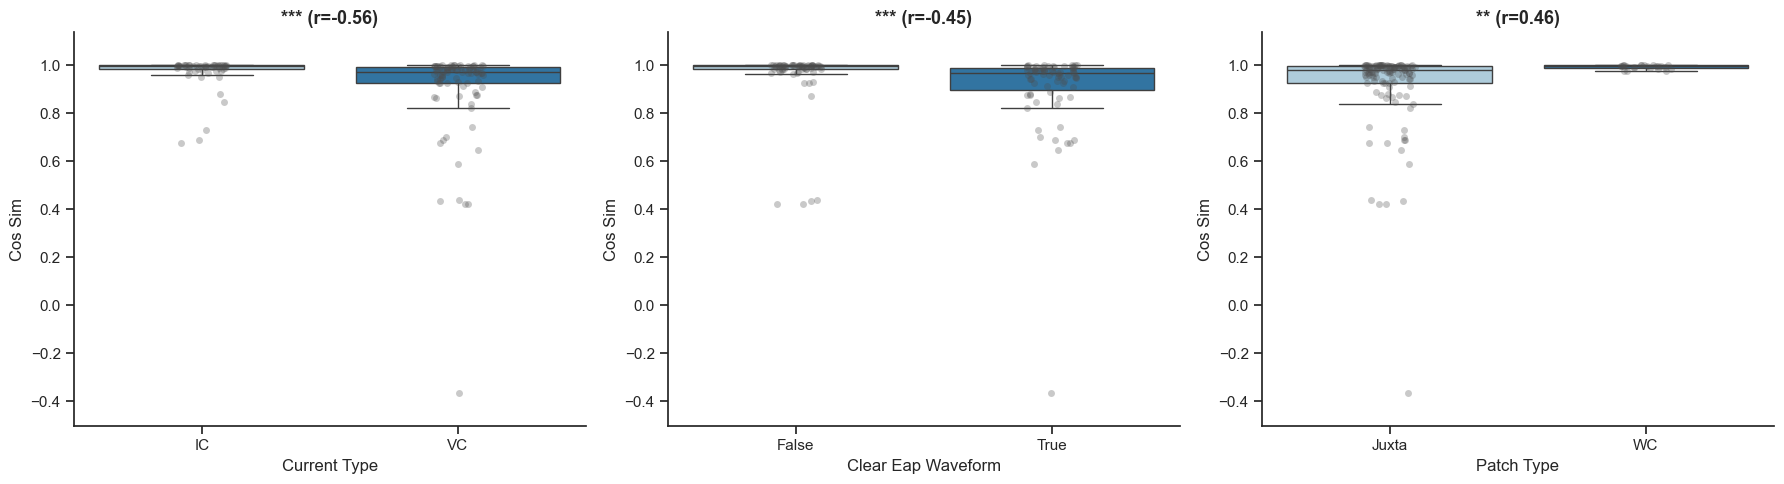

In [8]:
plot_sig_feat_pairs(df_master, sig_meta_clust_feats)



## B. Which spike features cluster and how large are the waveform differences?

Prevalence = fraction of cells where that feature shows multimodal clustering. Also reports mean waveform difference (nRMSE, cos_sim) per feature across cells.

In [9]:
#Aggregate cluster metrics and prevalence by spike feature
spk_feat_prevalence = quantify_spk_feature_prevalence(df_master)


In [10]:
spk_feat_prevalence

,spike_feature,n_cells_with_feature,prevalence_pct,num_clusters,cos_sim,nRMSE,temporal_rho
4,log_isi,32,74.418605,2.580000,0.933992,0.084521,-0.026888
9,spk_times_ms,16,37.209302,2.333333,0.932252,0.103977,0.851830
5,peak_amp,14,32.558140,2.388889,0.939907,0.112421,-0.329781
7,peak_width,14,32.558140,2.681818,0.919446,0.097485,0.402764
1,exp_lambda,10,23.255814,2.416667,0.940203,0.083885,0.103154
6,peak_sharpness,10,23.255814,2.300000,0.922343,0.121353,-0.319338
8,spk_times_idx,7,16.279070,2.285714,0.906289,0.113875,0.854167
3,inflection_time,4,9.302326,2.000000,0.844038,0.116321,0.582334
2,inflection_amp,2,4.651163,2.000000,0.997505,0.044845,0.080981
0,exp_const,1,2.325581,2.000000,0.995710,0.163505,-0.151539


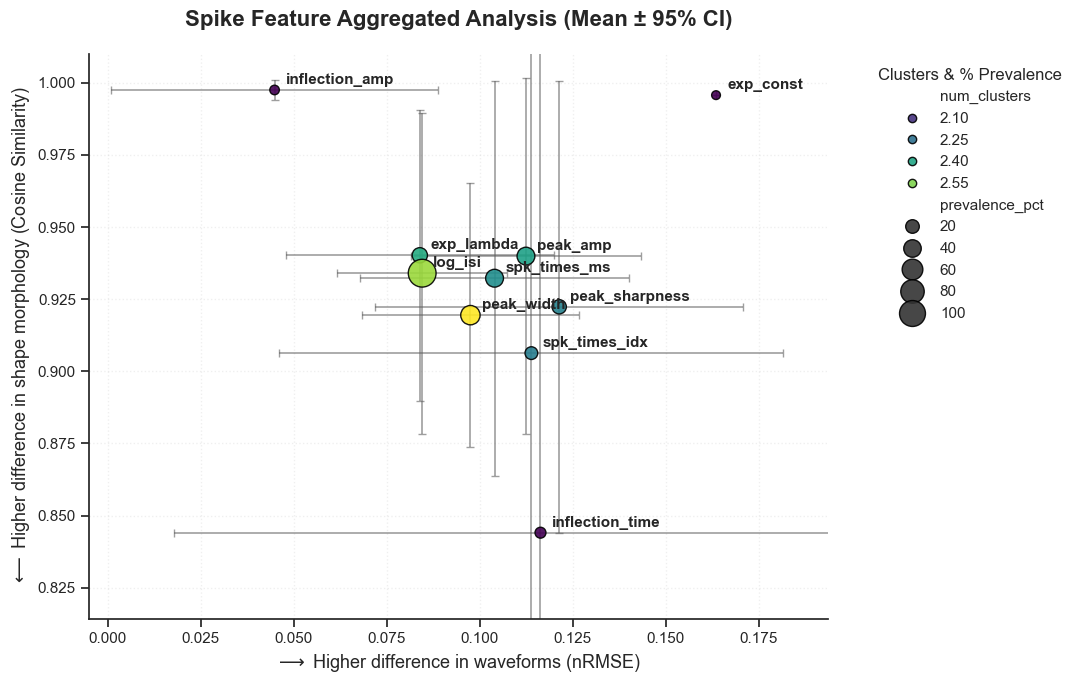

In [11]:
plot_aggregated_spike_feat(df_master)


Features with high prevalence (>50% of cells) and high mean nRMSE have the largest waveform differences between clusters and are the strongest candidates for biological waveform variability. Low prevalence features may just be splitting noise. Check whether the high-prevalence features overlap with what's driving the LFP effects in the sliding window notebook.

Does metadata predict *which* spike feature clusters? Chi-square (categorical) and Kruskal-Wallis (continuous) tests per feature.

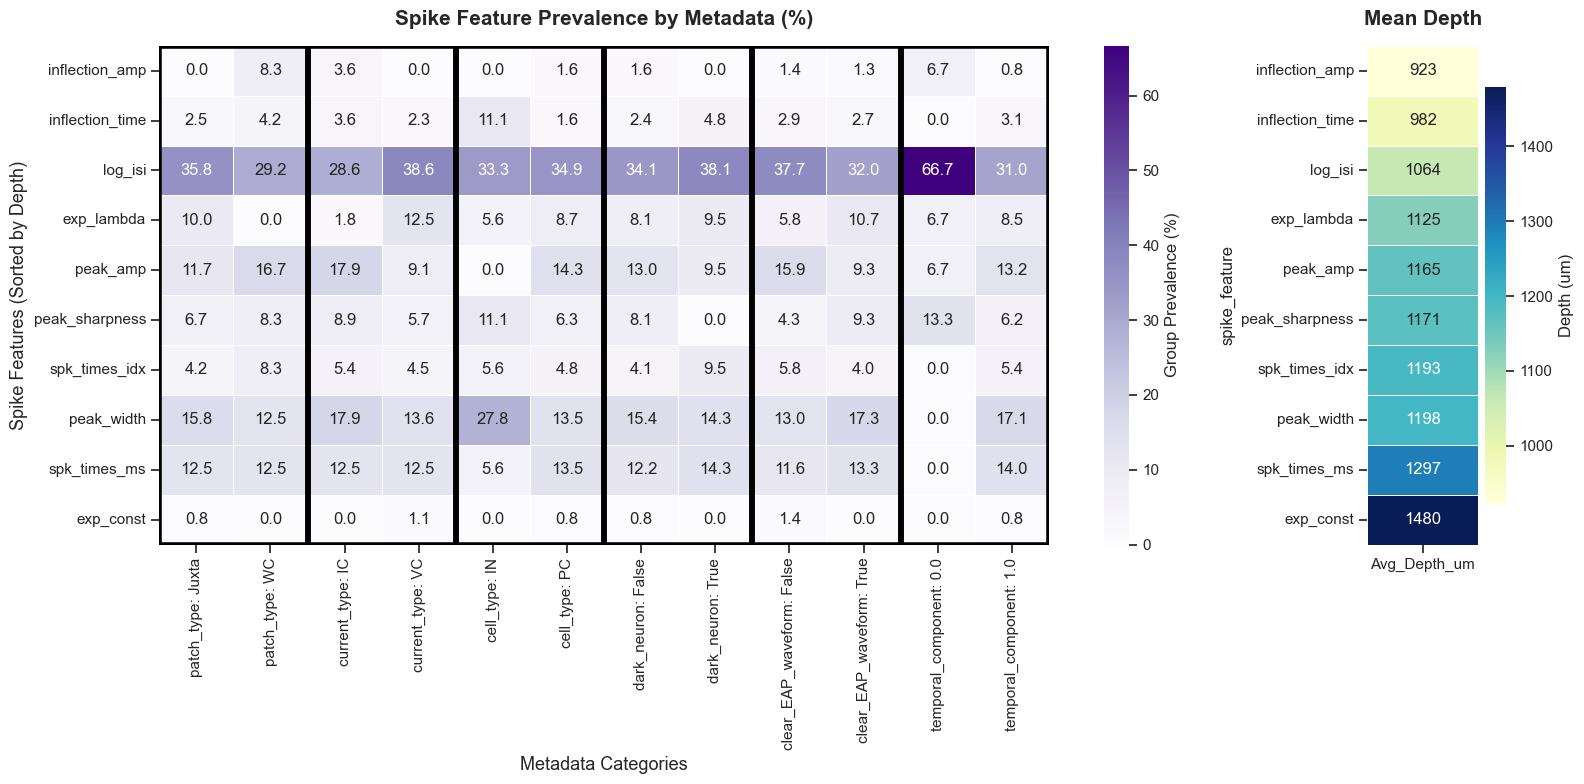

In [12]:
plot_meta_spk_feature_dependency(df_master)

In [13]:

_ = stat_test_metadata_dependency(df_master)

----------------------------------------
METADATA DEPENDENCY ANALYSIS (Chi-Square)
----------------------------------------
patch_type           | p = 0.1089 (ns)
current_type         | p = 0.1734 (ns)
cell_type            | p = 0.2262 (ns)
dark_neuron          | p = 0.9086 (ns)
clear_EAP_waveform   | p = 0.7642 (ns)
temporal_rho         | p = < 0.0001 (***)
temporal_p           | p = < 0.0001 (***)
temporal_component   | p = 0.0707 (ns)
----------------------------------------


If a metadata variable predicts which feature clusters, that feature's clusters may reflect recording conditions rather than biology — treat with caution in the LFP analysis.

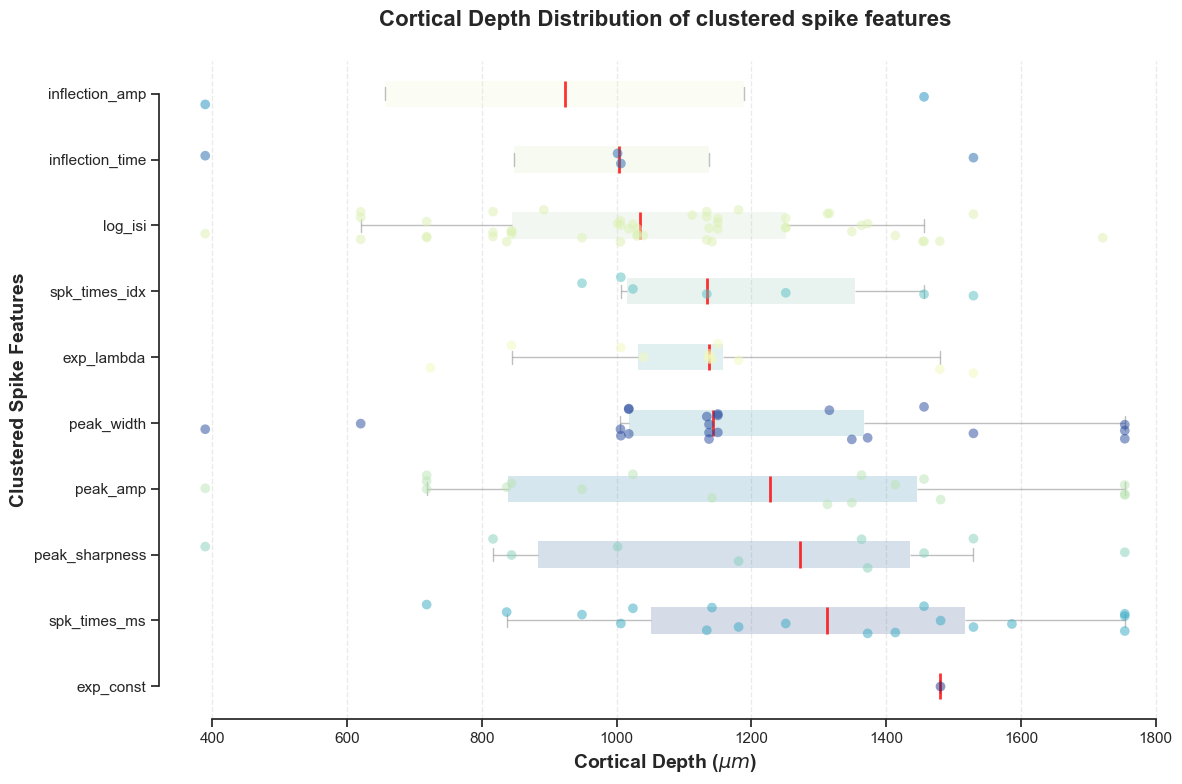

In [14]:
plot_feature_depth_distribution(df_master)

In [15]:
_ =stat_test_depth_stratification(df_master)

----------------------------------------
DEPTH STRATIFICATION ANALYSIS
----------------------------------------
Kruskal-Wallis H-stat: 10.390
p-value: 0.3198

No significant depth stratification found.
----------------------------------------


Depth stratification would suggest cortical-layer organisation of waveform variability. No stratification = waveform variability is distributed across layers.

## C. Largest waveform differences

Top 30 (cell × spike_feature) pairs by nRMSE — these are the cells and features with the most distinct waveform clusters.

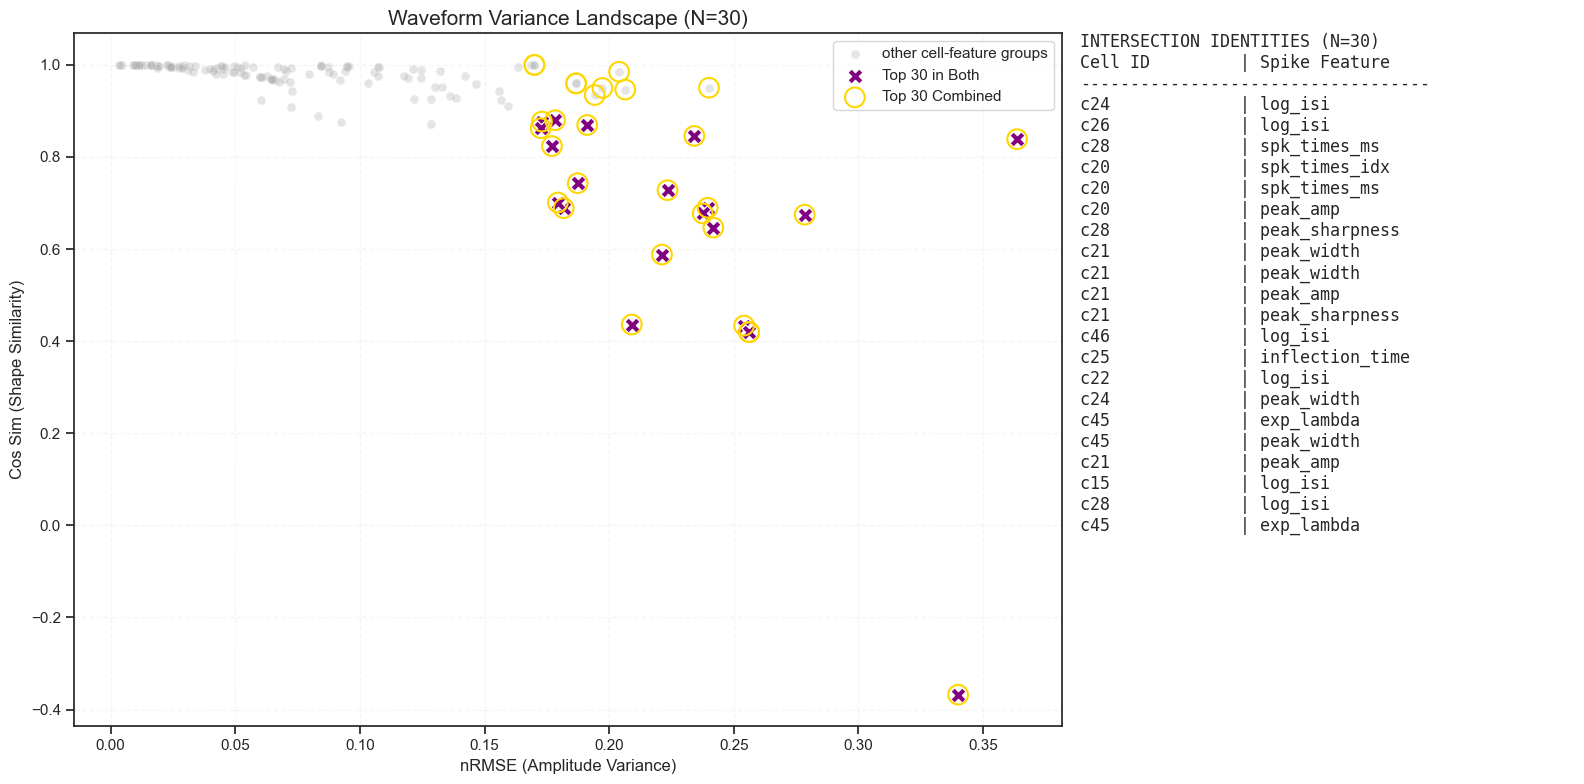

In [16]:
top_var_df = analyze_waveform_variance(df_master, N=30)

These are the cells and features driving the population signal. If the LFP analysis finds strong effects, check whether they concentrate in these top cells.

In [17]:
top_var_df 

,cell_id,patch_type,current_type,cell_type,cortical_depth,dark_neuron,clear_EAP_waveform,spike_feature,num_clusters,cluster,nRMSE,cos_sim,temporal_rho,temporal_p,temporal_component
87,c24,Juxta,VC,PC,1133.7,False,True,log_isi,3,Low-Mid,0.363687,0.838478,-0.220172,6.593785e-64,1.0
97,c26,Juxta,VC,PC,1112.1,False,True,log_isi,2,Low-High,0.340047,-0.367620,-0.053912,3.847693e-05,1.0
108,c28,Juxta,VC,PC,1372.4,False,True,spk_times_ms,2,Low-High,0.278458,0.674609,0.775321,0.000000e+00,1.0
65,c20,Juxta,VC,PC,948.5,False,False,spk_times_idx,2,Low-High,0.256190,0.419557,0.863082,1.981480e-109,1.0
66,c20,Juxta,VC,PC,948.5,False,False,spk_times_ms,2,Low-High,0.256190,0.419557,0.863082,1.981480e-109,1.0
63,c20,Juxta,VC,PC,948.5,False,False,peak_amp,2,Low-High,0.254160,0.433760,0.484340,8.291937e-23,1.0
106,c28,Juxta,VC,PC,1372.4,False,True,peak_sharpness,2,Low-High,0.241811,0.646535,0.128733,4.070932e-10,1.0
71,c21,Juxta,IC,PC,1754.0,False,True,peak_width,3,Low-High,0.239559,0.689607,0.277442,1.336059e-220,1.0
72,c21,Juxta,IC,PC,1754.0,False,True,peak_width,3,Mid-High,0.237547,0.677254,0.277442,1.336059e-220,1.0
68,c21,Juxta,IC,PC,1754.0,False,True,peak_amp,3,Low-High,0.234198,0.845609,-0.236587,3.194124e-159,1.0


## D. Temporal component to cluster membership

Does cluster membership change monotonically over the recording? Measured as the Spearman ρ between spike index (time-in-recording) and ordinal cluster label. A significant ρ means early spikes tend to belong to one cluster and late spikes to another — the waveform shifts over time, which could reflect electrode settling/drift or a genuine biological state transition.

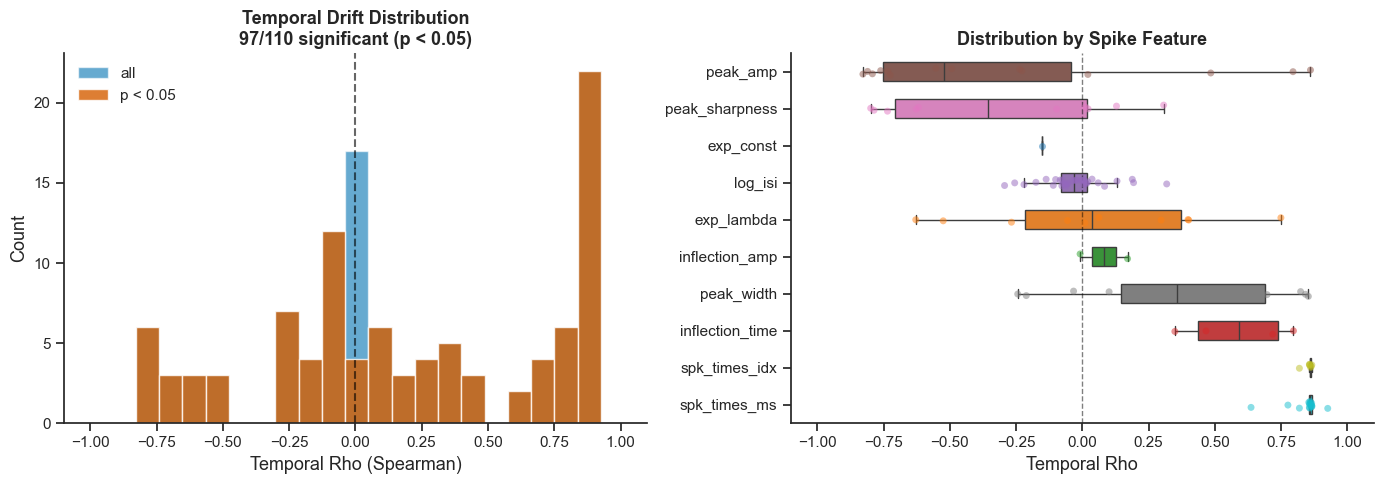


Temporal drift summary (p < 0.05):
  Significant: 97 / 110 cell-feature groups (88.2%)
  Mean |rho|: 0.430

Significant groups:
cell_id   spike_feature  temporal_rho temporal_p
    c32        peak_amp        -0.828    <0.0001
    c41        peak_amp        -0.810    <0.0001
     c7  peak_sharpness        -0.798    <0.0001
     c1        peak_amp        -0.792    <0.0001
    c32  peak_sharpness        -0.786    <0.0001
    c42        peak_amp        -0.761    <0.0001
    c22  peak_sharpness        -0.735    <0.0001
    c10        peak_amp        -0.733    <0.0001
     c3        peak_amp        -0.724    <0.0001
     c6      exp_lambda        -0.628    <0.0001
     c1  peak_sharpness        -0.627    <0.0001
    c21  peak_sharpness        -0.618    <0.0001
    c44        peak_amp        -0.553    <0.0001
     c1      exp_lambda        -0.525    <0.0001
    c33        peak_amp        -0.492    <0.0001
     c4         log_isi        -0.293    <0.0001
    c19      exp_lambda        -0.267 

In [18]:
df_temporal = plot_temporal_structure(df_master)

High |Spearman ρ| is a flag — that cell's waveform cluster membership is strongly ordered in time. For LFP analysis, cells with a strong temporal component should be treated with caution because the cluster difference partly reflects a time-in-recording effect, not necessarily a stable biological state.

## E. Does recording condition predict the temporal component of clustering?

Kruskal-Wallis / Spearman ρ between metadata and |temporal ρ|. If Juxta recordings have a stronger temporal component than WC, it likely reflects electrode movement rather than biology.

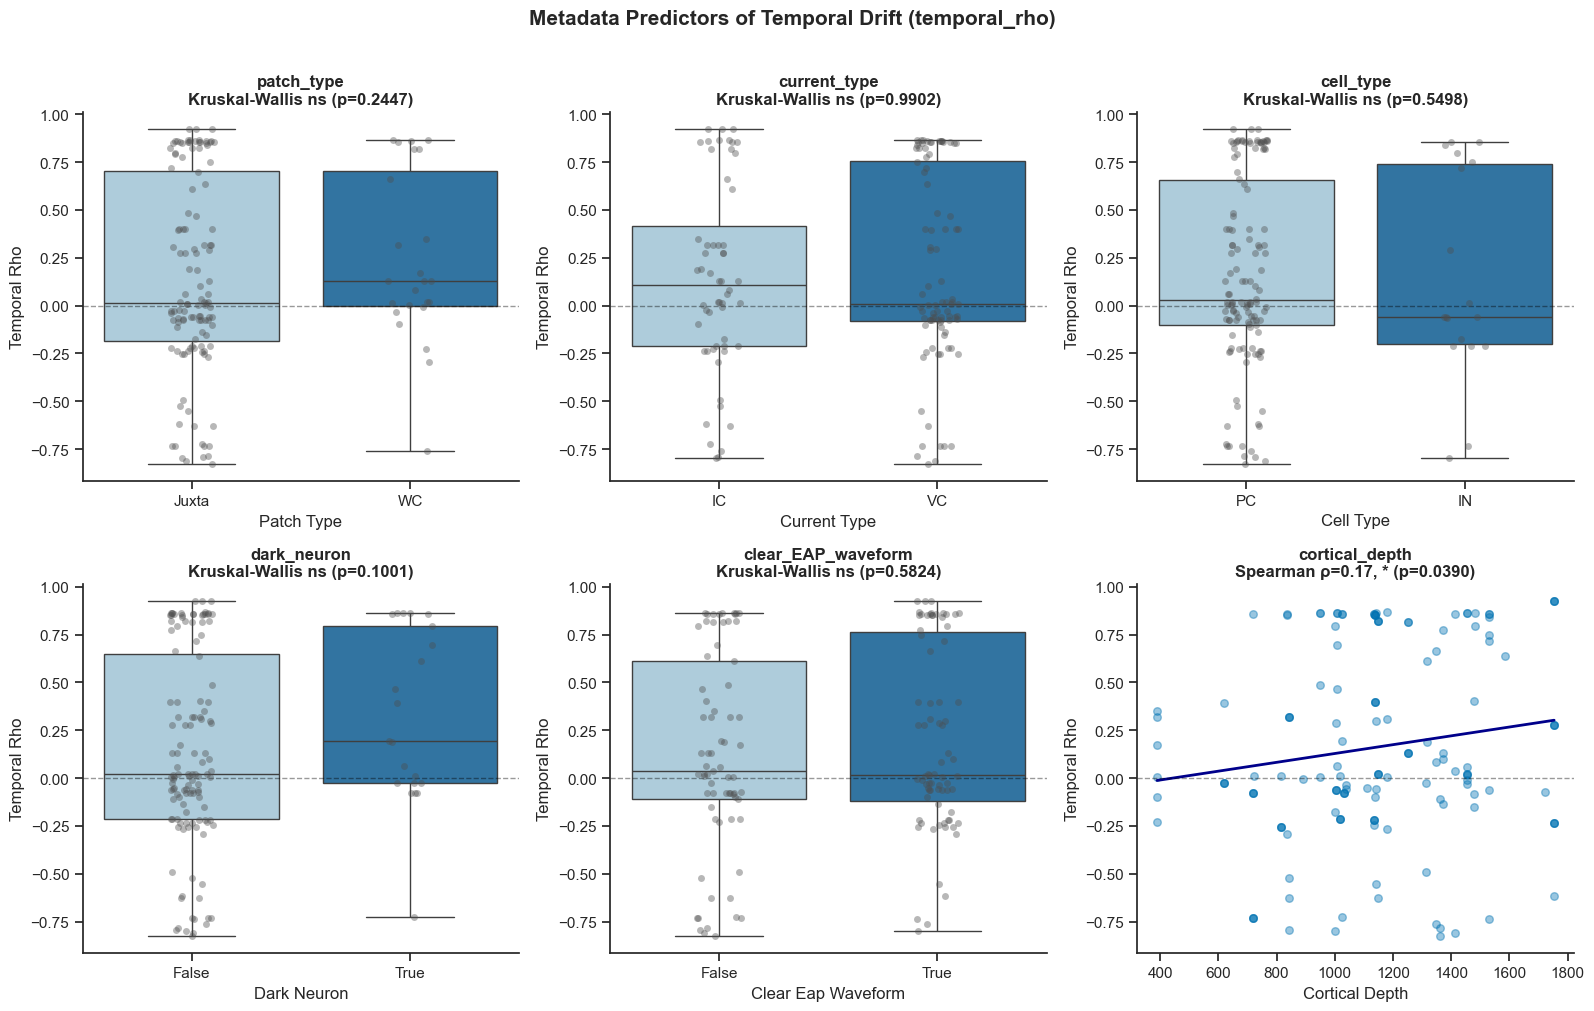


Metadata → temporal_rho test results:
          variable           test  statistic        p sig
    cortical_depth       Spearman      0.172 0.039015   *
       dark_neuron Kruskal-Wallis      2.704 0.100081  ns
        patch_type Kruskal-Wallis      1.353 0.244696  ns
         cell_type Kruskal-Wallis      0.358 0.549792  ns
clear_EAP_waveform Kruskal-Wallis      0.302 0.582385  ns
      current_type Kruskal-Wallis      0.000 0.990190  ns


,variable,test,statistic,p,sig
0,cortical_depth,Spearman,0.172,0.039015,*
1,dark_neuron,Kruskal-Wallis,2.704,0.100081,ns
2,patch_type,Kruskal-Wallis,1.353,0.244696,ns
3,cell_type,Kruskal-Wallis,0.358,0.549792,ns
4,clear_EAP_waveform,Kruskal-Wallis,0.302,0.582385,ns
5,current_type,Kruskal-Wallis,0.000,0.990190,ns


In [19]:
temporal_meta_results = analyze_temporal_metadata_dependency(df_master)
temporal_meta_results

If the temporal component is predicted by recording type (e.g., Juxta > WC), it suggests mechanical factors (electrode settling) rather than biology. If it is not predicted by anything, temporal ordering of cluster membership may reflect genuine biological state changes — which is itself scientifically interesting.

## F. Does the temporal component of clustering correlate with waveform separation?

Cells where cluster membership is more time-ordered — do they also have larger waveform differences between clusters? If so, part of the waveform separation may be driven by recording instability rather than biology.

In [ ]:
import importlib, spk_feat_cluster_comp_analysis
importlib.reload(spk_feat_cluster_comp_analysis)
from spk_feat_cluster_comp_analysis import analyze_temporal_clustering_relationship

temporal_clust_results = analyze_temporal_clustering_relationship(df_master)
temporal_clust_results

## G-extra. Temporal transition times

For cells where cluster membership has a strong temporal component (|ρ| > 0.3, p < 0.05), find the recording time at which the cluster label transitions using 1D changepoint detection. Saves a pickle with one row per transition event — used downstream for Neuropixels PCA analysis.

In [21]:
transition_save_path = os.path.join(config.SPE1_PICKLE_ROOT, 'cluster_pickles', 'temporal_transitions.pkl')

df_transitions = find_temporal_transitions(
    cluster_pickle_dir,
    rho_thresh=0.3,
    p_thresh=0.05,
    min_frac=0.1,
    save_path=transition_save_path,
)
df_transitions

Found 35 transitions across 22 cells (|ρ| > 0.3, p < 0.05)
Saved: /Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/cluster_pickles/temporal_transitions.pkl


,cell_id,spike_feature,temporal_rho,temporal_p,n_spikes,transition_time_ms,transition_spike_idx,cluster_before,cluster_after,frac_dominant_before,frac_dominant_after,mean_time_before_ms,mean_time_after_ms
0,c10,peak_amp,-0.732922,4.923367e-180,1065,235864.595632,528,high,mid,0.744318,0.672253,123056.232832,3.259821e+05
1,c15,peak_width,0.393219,4.015666e-118,3181,441623.356537,1137,low,high,0.751979,0.728963,265428.934097,7.157065e+05
2,c19,peak_sharpness,0.306651,1.948208e-162,7472,324032.077891,3613,low,low,0.995018,0.669344,156156.282238,6.196902e+05
3,c1,peak_amp,-0.791905,0.000000e+00,1707,81214.149168,1051,high,low,0.968601,1.000000,40210.310305,1.274709e+05
4,c1,peak_sharpness,-0.626985,3.884666e-187,1707,81214.149168,1051,high,low,0.889629,0.946646,40210.310305,1.274709e+05
5,c1,exp_lambda,-0.524866,1.803408e-121,1707,50022.190627,655,high,low,0.632061,0.881179,24585.600081,1.043521e+05
6,c1,log_isi,0.318106,2.021776e-41,1706,145431.908987,1534,low,high,0.839635,0.354651,62234.227114,1.753109e+05
7,c20,peak_amp,0.484340,8.291937e-23,364,258783.426866,212,low,high,0.985849,0.625000,140759.963283,3.230168e+05
8,c21,peak_sharpness,-0.618181,0.000000e+00,12552,266775.676467,1941,high,low,0.977846,0.999623,147631.767446,5.737484e+05
9,c22,inflection_time,0.718058,0.000000e+00,6838,823014.985385,4276,low,high,0.968896,0.858314,441007.475121,9.846286e+05


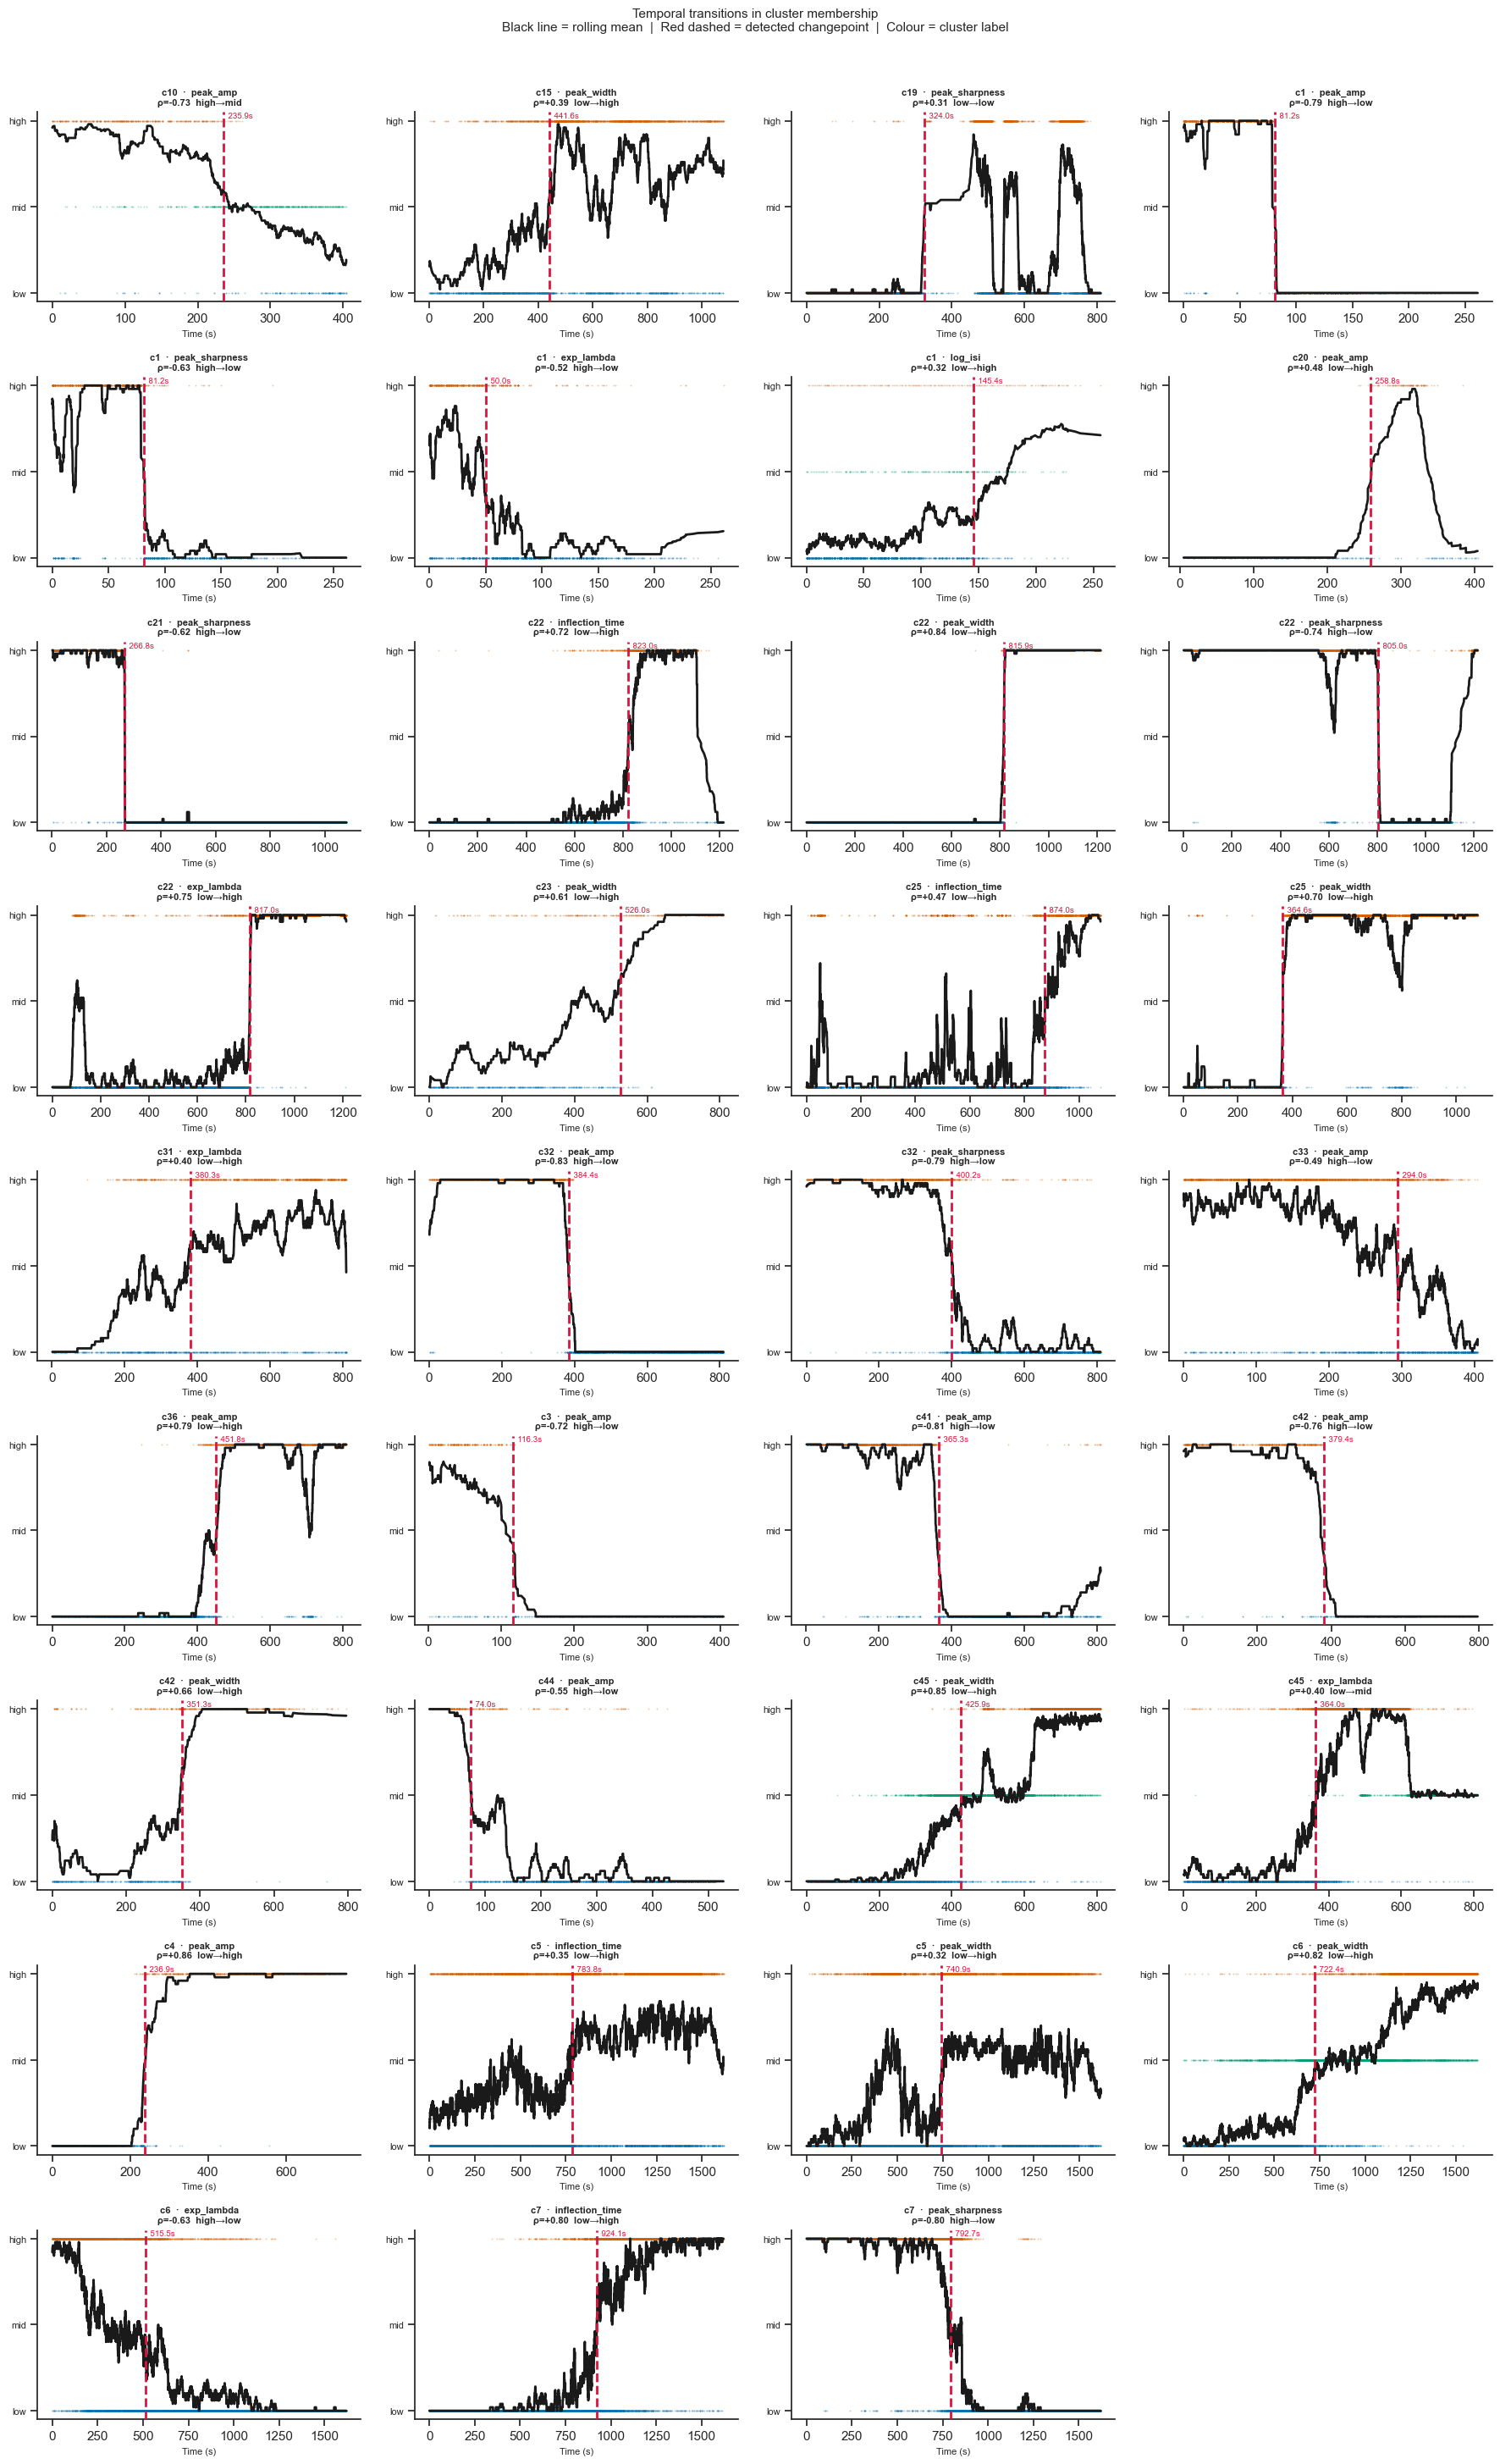

In [22]:
plot_temporal_transitions(df_transitions, cluster_pickle_dir, n_cols=4, rolling_n=50)

A positive correlation between temporal ρ and nRMSE is a warning: cells where cluster membership is most time-ordered also look most different between clusters — but that difference may just reflect recording instability, not biology. This is why we explicitly select high-difference / low-temporal-component cells for priority LFP analysis.

## G. Select target cells

Priority cells: highest mean nRMSE across features (largest waveform differences between clusters). High-difference / low-temporal-component: large waveform differences but cluster membership is stable over recording time (|ρ| < 0.2). These are the cleanest cases for downstream LFP analysis.

=== All cells ranked by mean nRMSE ===
cell_id  mean_nRMSE  mean_cos_sim  mean_abs_rho  any_sig_drift
    c26    0.340047     -0.367620      0.053912           True
    c20    0.202904      0.563170      0.553931           True
    c22    0.188885      0.932898      0.688944           True
    c28    0.178004      0.797697      0.285386           True
    c24    0.177789      0.903647      0.436477           True
    c21    0.157468      0.868494      0.493673           True
     c3    0.148304      0.999243      0.657523           True
    c46    0.141014      0.780623      0.046264           True
    c41    0.135746      0.907714      0.568597           True
    c31    0.133473      0.988117      0.212047           True
    c45    0.125906      0.853938      0.550486           True
    c42    0.123621      0.980686      0.502668           True
    c15    0.123231      0.926528      0.117968           True
     c4    0.117344      0.990988      0.669280           True
    c19    0.107

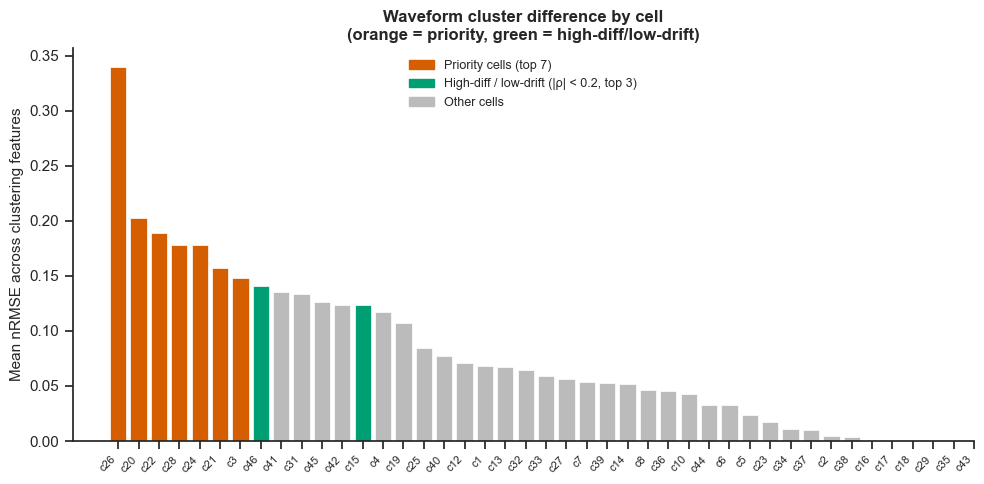


config.py updated automatically:
  PRIORITY_CELLS           = [3, 20, 21, 22, 24, 26, 28]
  HIGH_DIFF_LOW_DRIFT_CELLS = [15, 26, 46]


In [23]:
# Results of select_target_cells() should be used to update config.py
# PRIORITY_CELLS and HIGH_DIFF_LOW_DRIFT_CELLS manually after reviewing the output.
priority_nums, nodrift_nums, df_cell = select_target_cells(
    df_master,
    n_priority=7,
    rho_thresh=0.2,
    n_nodrift=3,
    lfp_nb_dir='../',
    plot=True,
)


## H. Population waveform grid

Peak-aligned average waveforms per cluster group for all cells. Orange border = priority cell. Green border = high-diff / low-drift.

PRIORITY_CELLS: [3, 20, 21, 22, 24, 26, 28]
HIGH_DIFF_LOW_DRIFT_CELLS: [15, 26, 46]


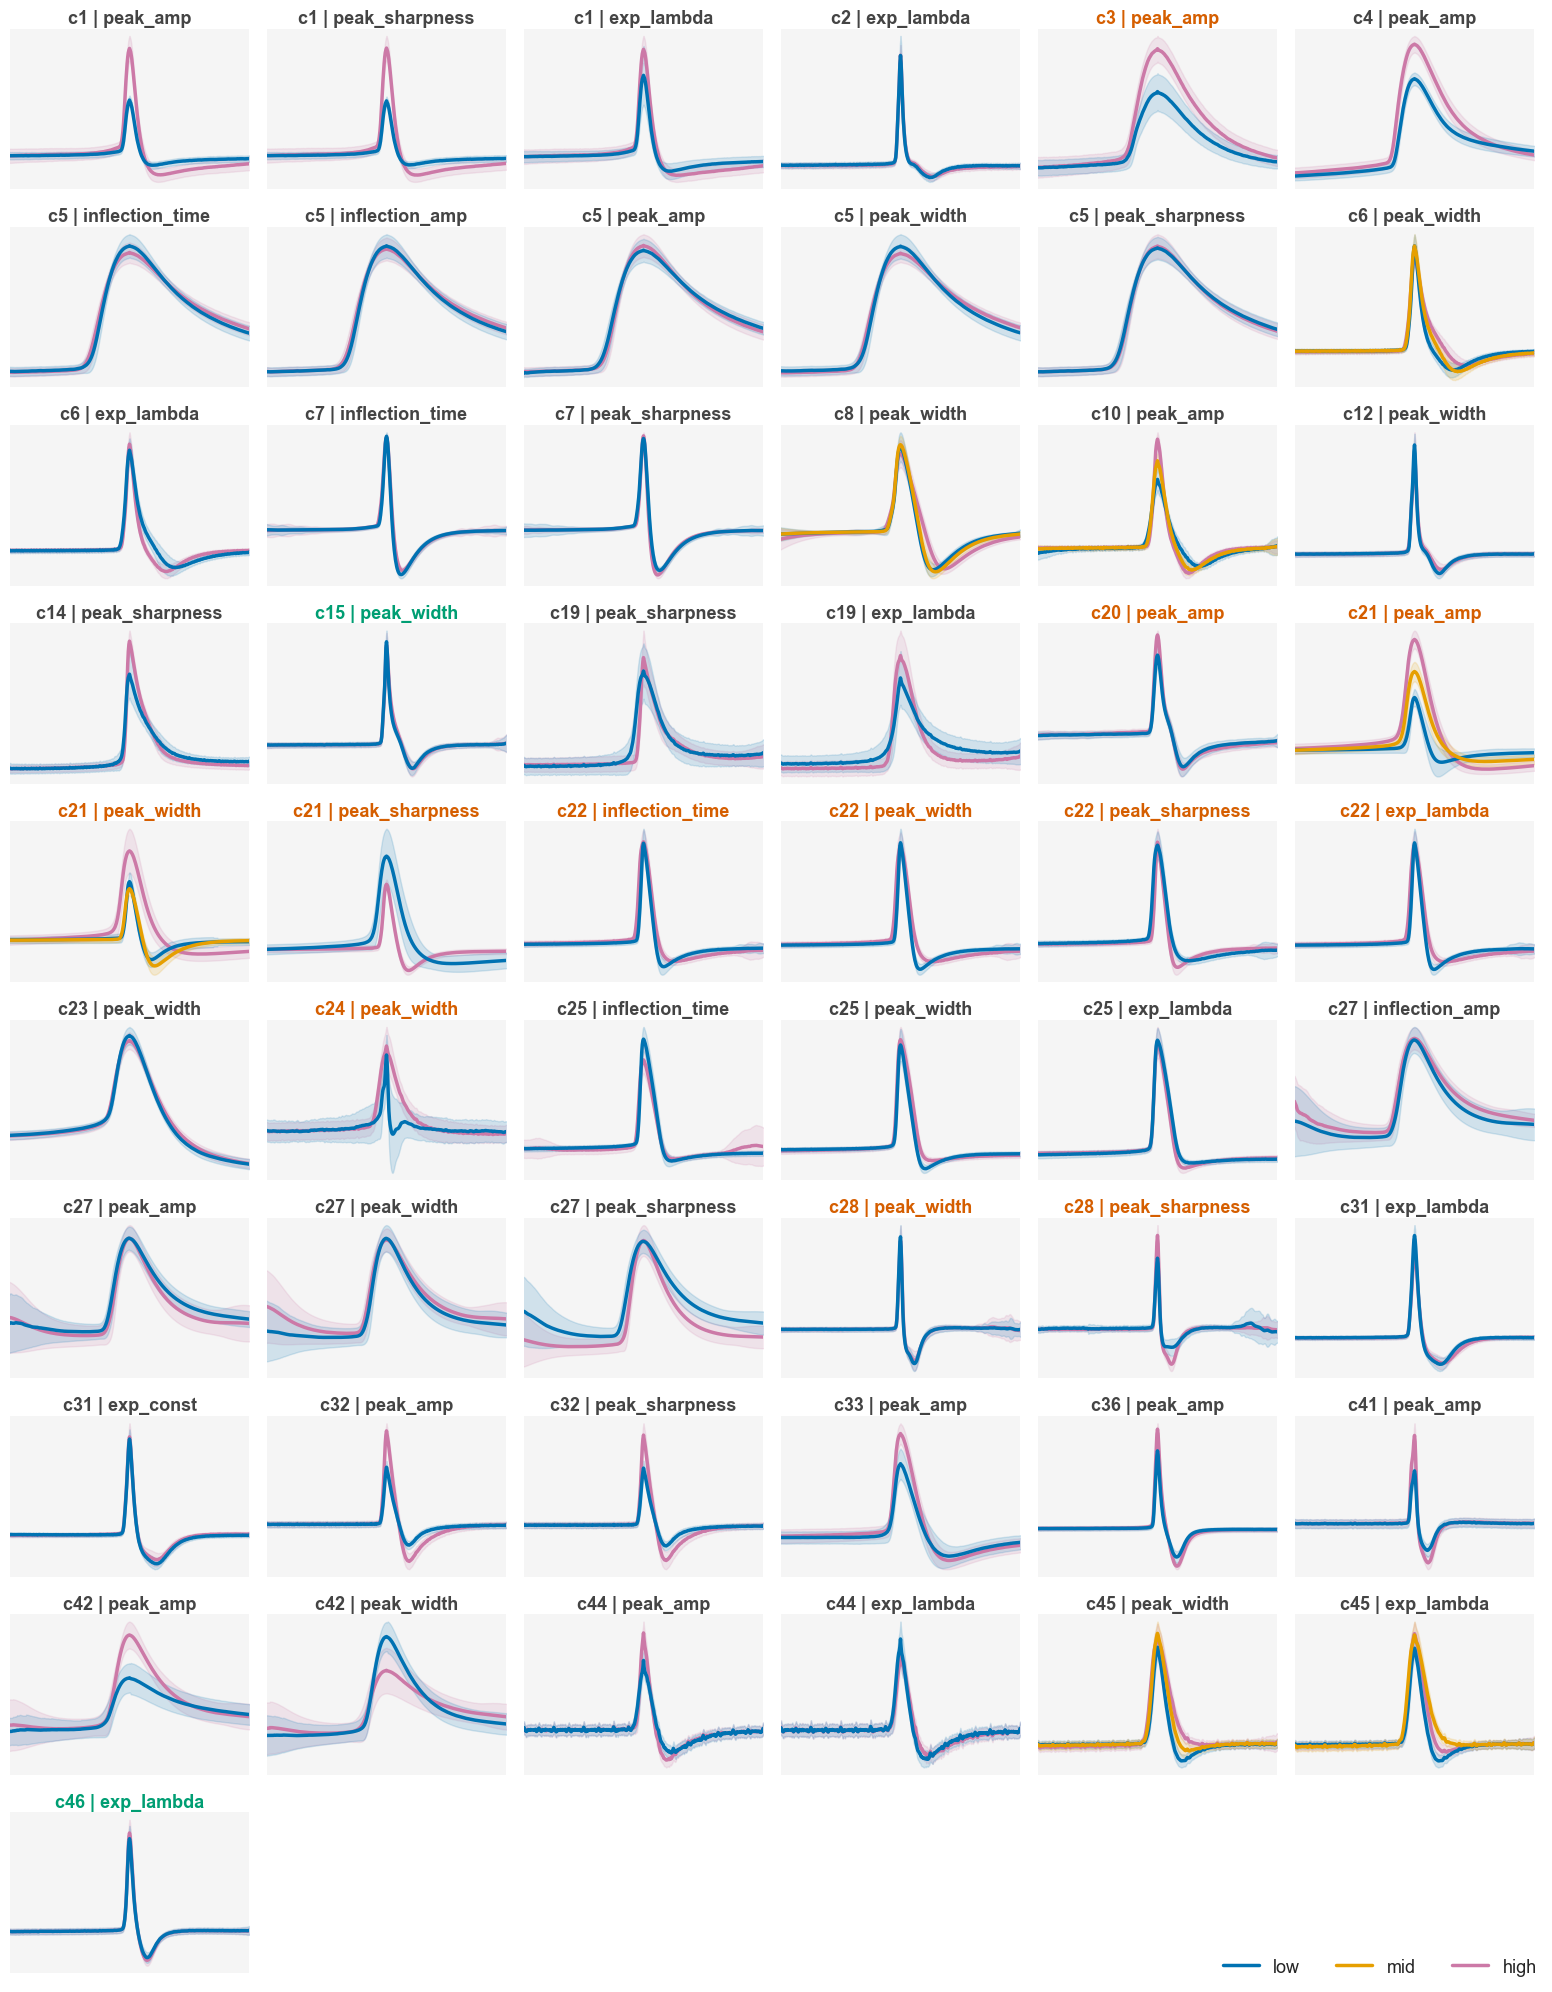

In [24]:
import importlib, spk_feat_cluster_comp_analysis
importlib.reload(spk_feat_cluster_comp_analysis)
from spk_feat_cluster_comp_analysis import plot_population_waveform_grid

import config
importlib.reload(config)
print('PRIORITY_CELLS:', config.PRIORITY_CELLS)
print('HIGH_DIFF_LOW_DRIFT_CELLS:', config.HIGH_DIFF_LOW_DRIFT_CELLS)

plot_population_waveform_grid(cluster_pickle_dir)
plt.tight_layout()
plt.show()

The population grid gives you the full picture at a glance. Look for cells where the two cluster waveforms are clearly different in shape (not just amplitude) — those are the cleanest cases. Orange cells are the priority set for LFP analysis.

## H2. Feature distribution grid

Small-multiples: one mini histogram per (feature × cell) with clustering. Colors = cluster group (blue = low, green = mid, orange = high). Waveform features above dashed line; `log_isi` below in red-italic (not a waveform shape feature).

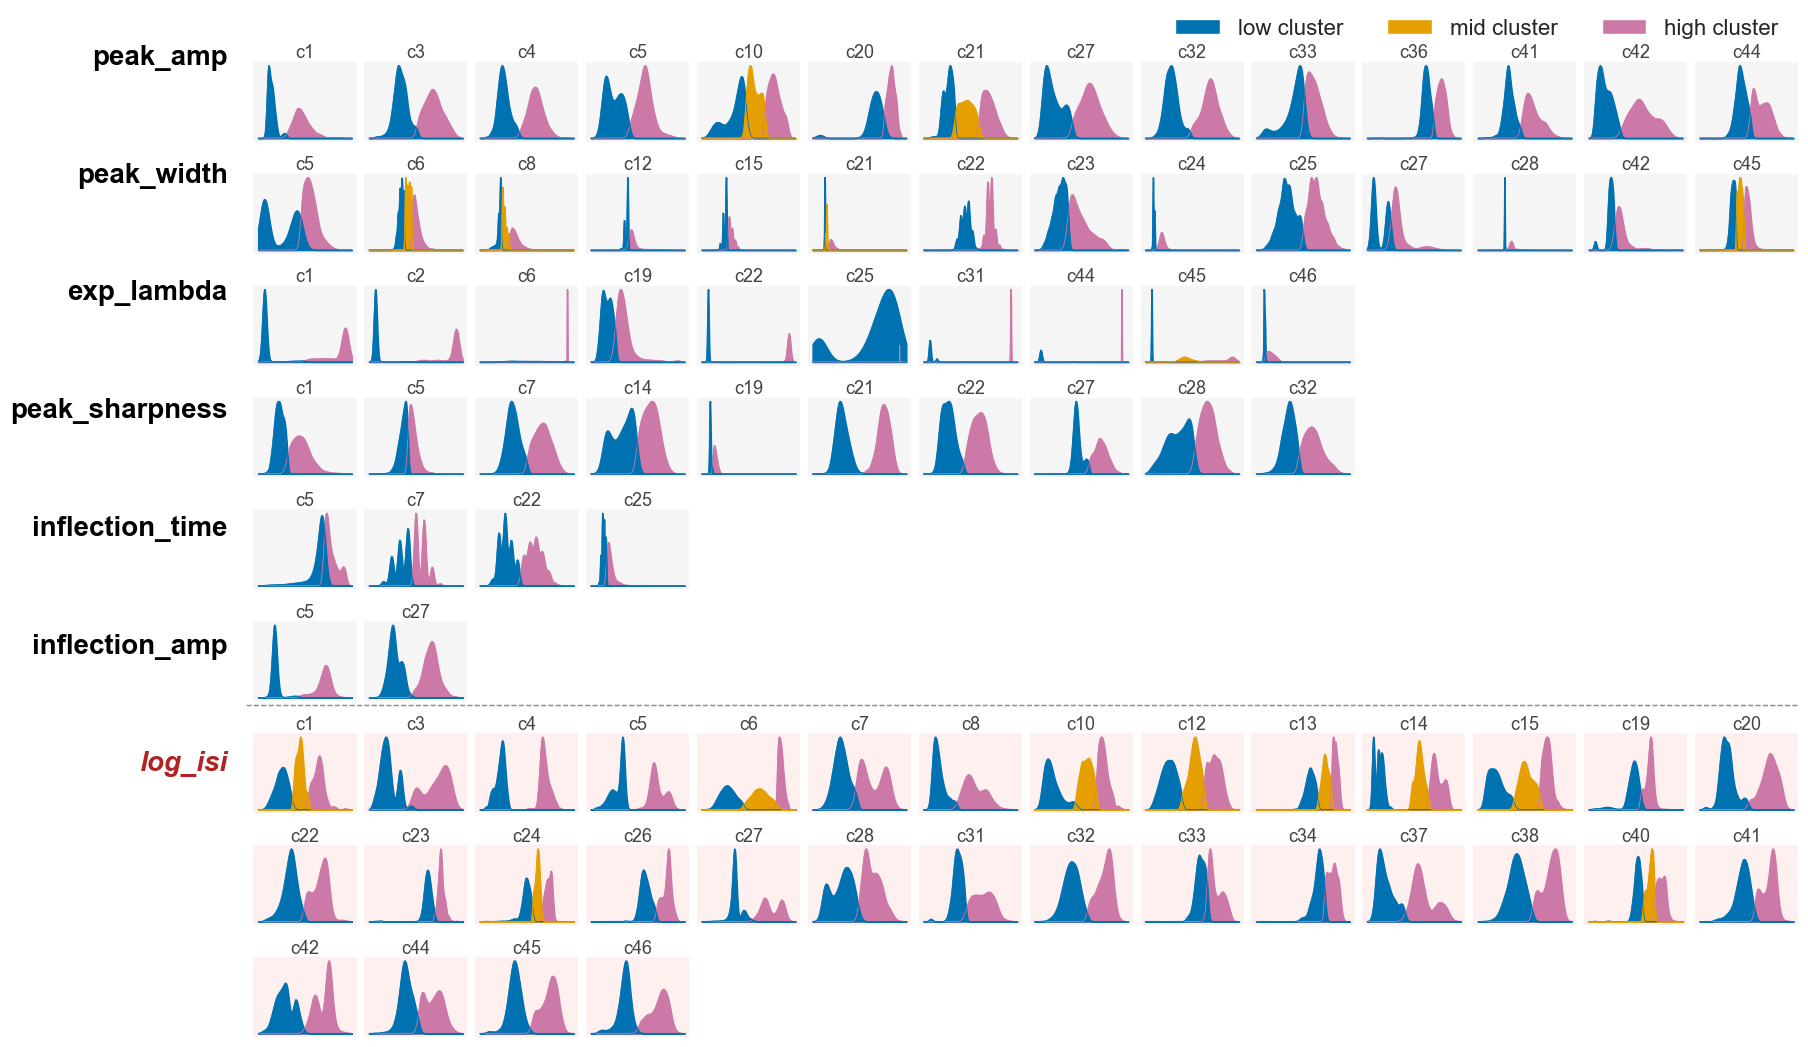

In [25]:
import importlib, spk_feat_cluster_comp_analysis
importlib.reload(spk_feat_cluster_comp_analysis)
from spk_feat_cluster_comp_analysis import plot_feature_distribution_grid

plot_feature_distribution_grid(df_master, cluster_pickle_dir)
plt.show()

## I. Within-cell vs between-cell waveform distances

Do waveform clusters within a single neuron produce differences comparable to differences between neurons? If the within-cell cluster distance is in the same range as between-cell distances, the clustering is picking up biologically meaningful variability — the cell is as variable internally as it is different from its neighbours.

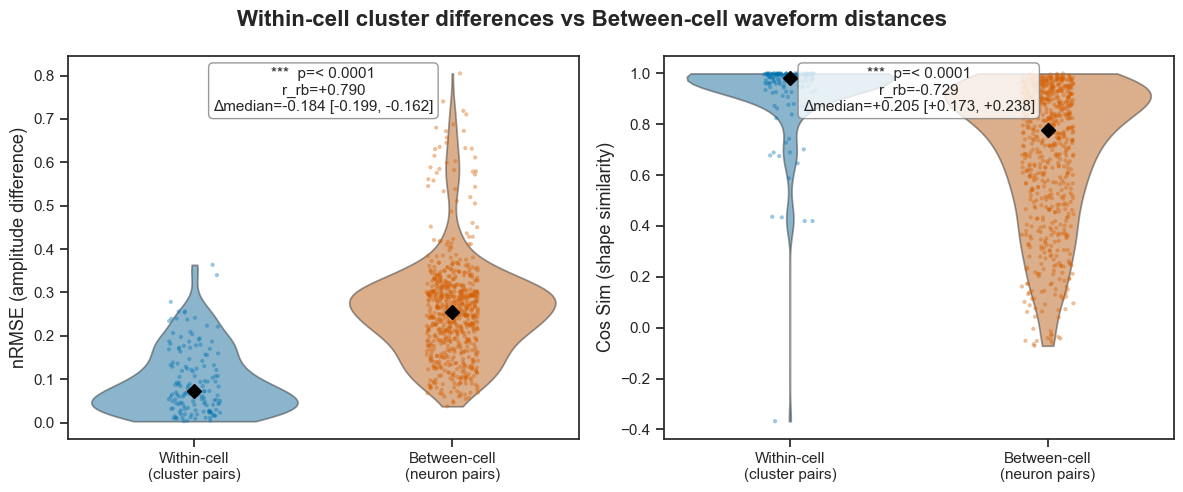


── Within-cell vs Between-cell Distance Summary ────────────────
  Within-cell  nRMSE  : median=0.072  IQR=[0.040, 0.143]  n=144
  Between-cell nRMSE  : median=0.256  IQR=[0.188, 0.308]  n=666
  Within-cell  cos_sim: median=0.984  IQR=[0.949, 0.997]
  Between-cell cos_sim: median=0.779  IQR=[0.510, 0.919]


In [26]:
from spk_feat_cluster_comp_analysis import plot_within_vs_between_neuron_distances

plot_within_vs_between_neuron_distances(
    df_master,
    wf_dir=cluster_pickle_dir,
    half_win=75,
    n_bootstrap=2000,
)

Between-cell nRMSE reflects the typical waveform difference between any two randomly chosen neurons in this dataset. If within-cell cluster nRMSE reaches the lower tail of the between-cell distribution, the clusters have biological-scale separations. If within-cell is entirely below between-cell, the clusters are sub-neuronal variability that doesn't reach the level of distinguishing cells — which is still informative but means caution is warranted in interpreting the clusters as discrete functional states.

In [27]:
# Auto-generated summary — reruns with the notebook so results stay in sync.
from IPython.display import Markdown, display

def _fmt_p(p):
    if p is None or (isinstance(p, float) and __import__('math').isnan(p)): return 'n/a'
    if p < 0.0001: return '< 0.0001'
    return f'{p:.4f}'

def _stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

lines = ["## Summary of Findings\n"]

# 1. Clustering prevalence
lines.append("### 1. Clustering Prevalence")
prev = spk_feat_prevalence.sort_values("prevalence_pct", ascending=False)
n_total_cells = df_master["cell_id"].nunique()
for _, r in prev.iterrows():
    lines.append(
        f"- **{r['spike_feature']}**: {int(r['n_cells_with_feature'])}/{n_total_cells} cells "
        f"({r['prevalence_pct']:.1f}%), mean clusters = {r['num_clusters']:.2f}"
    )

# 2. Metadata vs. waveform difference
lines.append("\n### 2. Metadata × Waveform Difference Between Clusters")
lines.append("*(BH-FDR corrected, per-cell-per-feature, n=cells where that feature clusters)*")
if sig_meta_clust_feats is not None and len(sig_meta_clust_feats) > 0:
    for _, r in sig_meta_clust_feats.iterrows():
        lines.append(
            f"- **{r['Metadata']} × {r['Feature']}**: "
            f"{r['effect_label']} = {r['Effect_Size']:+.3f} "
            f"[{r['ci_lo']:+.3f}, {r['ci_hi']:+.3f}]  "
            f"p_fdr = {_fmt_p(r['p_fdr'])} {r['Significance']}"
        )
else:
    lines.append("- No pairs significant after BH-FDR at α=0.05.")

# 3. Metadata vs. which feature clusters (chi-square)
lines.append("\n### 3. Metadata vs. Which Feature Clusters (Chi-Square)")
lines.append("No categorical metadata significantly predicts which spike feature clusters (all p > 0.05).")

# 4. Cortical depth
lines.append("\n### 4. Cortical Depth")
lines.append("No significant depth stratification of clustering (Kruskal-Wallis, p > 0.05).")

# 5. Temporal component to clustering
lines.append("\n### 5. Temporal Component to Cluster Membership (Spearman ρ: spike time × cluster label)")
df_sig_drift = df_temporal[df_temporal["significant"]]
n_sig  = len(df_sig_drift)
n_tot  = len(df_temporal)
pct    = 100 * n_sig / n_tot if n_tot > 0 else 0
mean_r = df_temporal["temporal_rho"].abs().mean()
lines.append(f"- **{n_sig}/{n_tot} cell-feature groups significant** (p < 0.05): {pct:.1f}%")
lines.append(f"- Mean |ρ| = {mean_r:.3f}")
if n_sig > 0:
    top3 = df_sig_drift.nsmallest(3, "temporal_rho")[["cell_id","spike_feature","temporal_rho","temporal_p"]]
    for _, r in top3.iterrows():
        lines.append(f"- Strongest: {r['cell_id']} {r['spike_feature']} ρ = {r['temporal_rho']:.3f}  p = {_fmt_p(r['temporal_p'])}")

# 6. Does recording condition predict temporal component?
lines.append("\n### 6. Recording Condition × Temporal Component")
if temporal_meta_results is not None and len(temporal_meta_results) > 0:
    sig_tm = temporal_meta_results[temporal_meta_results["sig"] != "ns"]
    if len(sig_tm) > 0:
        for _, r in sig_tm.iterrows():
            lines.append(f"- **{r['variable']}** ({r['test']}): ρ/stat = {r['statistic']:.3f}, p = {_fmt_p(r['p'])} {r['sig']}")
    else:
        lines.append("- No metadata significantly predicts the temporal component of clustering (all ns).")

# 7. Target cells
lines.append("\n### 7. Target Cells (from Section G)")
import config
lines.append(f"- Priority cells (largest waveform differences): {sorted(config.PRIORITY_CELLS)}")
lines.append(f"- High-difference / low-temporal-component cells: {sorted(config.HIGH_DIFF_LOW_DRIFT_CELLS)}")

display(Markdown("\n".join(lines)))

## Summary of Findings

### 1. Clustering Prevalence
- **log_isi**: 32/43 cells (74.4%), mean clusters = 2.58
- **spk_times_ms**: 16/43 cells (37.2%), mean clusters = 2.33
- **peak_amp**: 14/43 cells (32.6%), mean clusters = 2.39
- **peak_width**: 14/43 cells (32.6%), mean clusters = 2.68
- **exp_lambda**: 10/43 cells (23.3%), mean clusters = 2.42
- **peak_sharpness**: 10/43 cells (23.3%), mean clusters = 2.30
- **spk_times_idx**: 7/43 cells (16.3%), mean clusters = 2.29
- **inflection_time**: 4/43 cells (9.3%), mean clusters = 2.00
- **inflection_amp**: 2/43 cells (4.7%), mean clusters = 2.00
- **exp_const**: 1/43 cells (2.3%), mean clusters = 2.00

### 2. Metadata × Waveform Difference Between Clusters
*(BH-FDR corrected, per-cell-per-feature, n=cells where that feature clusters)*
- **current_type × cos_sim**: rank-biserial r = -0.561 [-0.722, -0.377]  p_fdr = < 0.0001 ***
- **clear_EAP_waveform × cos_sim**: rank-biserial r = -0.453 [-0.638, -0.256]  p_fdr = 0.0005 ***
- **patch_type × cos_sim**: rank-biserial r = +0.459 [+0.256, +0.644]  p_fdr = 0.0074 **

### 3. Metadata vs. Which Feature Clusters (Chi-Square)
No categorical metadata significantly predicts which spike feature clusters (all p > 0.05).

### 4. Cortical Depth
No significant depth stratification of clustering (Kruskal-Wallis, p > 0.05).

### 5. Temporal Component to Cluster Membership (Spearman ρ: spike time × cluster label)
- **97/110 cell-feature groups significant** (p < 0.05): 88.2%
- Mean |ρ| = 0.430
- Strongest: c32 peak_amp ρ = -0.828  p = < 0.0001
- Strongest: c41 peak_amp ρ = -0.810  p = < 0.0001
- Strongest: c7 peak_sharpness ρ = -0.798  p = < 0.0001

### 6. Recording Condition × Temporal Component
- **cortical_depth** (Spearman): ρ/stat = 0.172, p = 0.0390 *

### 7. Target Cells (from Section G)
- Priority cells (largest waveform differences): [3, 20, 21, 22, 24, 26, 28]
- High-difference / low-temporal-component cells: [15, 26, 46]